# BhuNirvighna AI - Model Development Notebook

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/raw/BhuNirvighna_Land_Acquisition_Dataset.csv")
df.head()

,Project_ID,State,District,Project_Type,Land_Required_Hectare,Land_Acquired_Hectare,Affected_Families,Displaced_Families,Sanction_Date,3A_Notification_Date,...,Compensation_Amount_Crore,RR_Amount_Crore,Compensation_Status,R&R_Progress_Percent,Legal_Disputes_Count,Possession_Status,Historical_Delay_Days,Risk_Score_0_100,Delay_Label,Data_Basis
0,BHNV-00001,West Bengal,Hooghly,Irrigation,169.36,107.95,304,50,2019-05-03,2019-08-29,...,207.80,13.46,Partially paid,97.7,4,Pending,736,58,0,Synthetic prototype; fields modeled on public ...
1,BHNV-00002,Madhya Pradesh,Ujjain,Urban Development,60.51,57.81,94,15,2021-04-29,2023-02-26,...,124.42,6.28,Mostly paid,93.8,4,Substantially complete,1745,49,0,Synthetic prototype; fields modeled on public ...
2,BHNV-00003,Odisha,Sambalpur,Urban Development,84.41,33.67,164,26,2018-11-25,2019-12-18,...,214.35,10.61,Pending,100.0,4,Pending,2240,68,1,Synthetic prototype; fields modeled on public ...
3,BHNV-00004,Gujarat,Ahmedabad,Railway,68.02,46.03,129,24,2018-07-05,2019-05-16,...,223.83,11.34,Partially paid,100.0,1,Partial possession,602,57,0,Synthetic prototype; fields modeled on public ...
4,BHNV-00005,West Bengal,Kolkata,Irrigation,29.96,23.30,48,8,2022-03-02,2023-01-22,...,53.02,5.04,Partially paid,86.7,1,Partial possession,1438,56,0,Synthetic prototype; fields modeled on public ...


In [3]:
df.shape

(2000, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Project_ID                 2000 non-null   object 
 1   State                      2000 non-null   object 
 2   District                   2000 non-null   object 
 3   Project_Type               2000 non-null   object 
 4   Land_Required_Hectare      2000 non-null   float64
 5   Land_Acquired_Hectare      2000 non-null   float64
 6   Affected_Families          2000 non-null   int64  
 7   Displaced_Families         2000 non-null   int64  
 8   Sanction_Date              2000 non-null   object 
 9   3A_Notification_Date       2000 non-null   object 
 10  3D_Notification_Date       2000 non-null   object 
 11  Award_Date                 2000 non-null   object 
 12  Payment_Date               2000 non-null   object 
 13  Possession_Date            2000 non-null   objec

In [5]:
df.isnull().sum()

Project_ID                   0
State                        0
District                     0
Project_Type                 0
Land_Required_Hectare        0
Land_Acquired_Hectare        0
Affected_Families            0
Displaced_Families           0
Sanction_Date                0
3A_Notification_Date         0
3D_Notification_Date         0
Award_Date                   0
Payment_Date                 0
Possession_Date              0
Compensation_Amount_Crore    0
RR_Amount_Crore              0
Compensation_Status          0
R&R_Progress_Percent         0
Legal_Disputes_Count         0
Possession_Status            0
Historical_Delay_Days        0
Risk_Score_0_100             0
Delay_Label                  0
Data_Basis                   0
dtype: int64

## 2. Data Cleaning

In [6]:
date_cols = ['Sanction_Date','3A_Notification_Date','3D_Notification_Date',
             'Award_Date','Payment_Date','Possession_Date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c])

In [7]:
# Flag rows where dates are out of logical order
df['date_issue'] = (
    (df['3D_Notification_Date'] < df['3A_Notification_Date']) |
    (df['Award_Date'] < df['3D_Notification_Date'])
)
print(df['date_issue'].sum(), "rows have date order issues")

1033 rows have date order issues


In [8]:
# Drop rows with date order issues for clean training
df_clean = df[~df['date_issue']].copy()
print("Remaining rows:", df_clean.shape[0])

Remaining rows: 967


In [9]:
# Save cleaned data
os.makedirs("data/cleaned", exist_ok=True)
df_clean.to_csv("data/cleaned/cleaned_data.csv", index=False)

## 3. Exploratory Visuals (saved to visuals for the PPT)

In [36]:
os.makedirs("visuals", exist_ok=True)

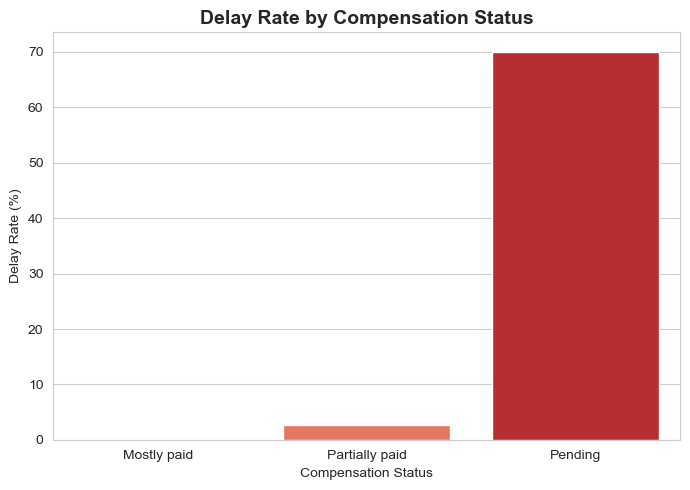

In [37]:
# Chart 1 — Delay Rate by Compensation Status
plt.figure(figsize=(7,5))
comp_delay = df_clean.groupby('Compensation_Status')['Delay_Label'].mean().sort_values() * 100
sns.barplot(x=comp_delay.index, y=comp_delay.values, hue=comp_delay.index, palette="Reds", legend=False)
plt.title("Delay Rate by Compensation Status", fontsize=14, fontweight='bold')
plt.ylabel("Delay Rate (%)")
plt.xlabel("Compensation Status")
plt.tight_layout()
plt.savefig("visuals/01_delay_by_compensation_status.png", dpi=200)
plt.show()

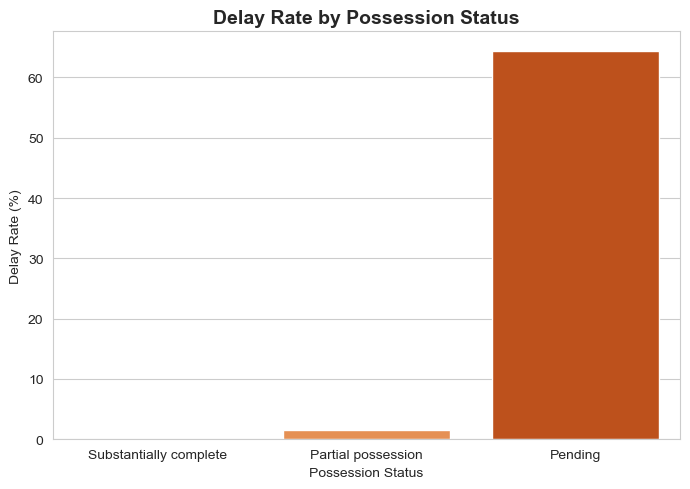

In [38]:
# Chart 2 — Delay Rate by Possession Status
plt.figure(figsize=(7,5))
poss_delay = df_clean.groupby('Possession_Status')['Delay_Label'].mean().sort_values() * 100
sns.barplot(x=poss_delay.index, y=poss_delay.values, hue=poss_delay.index, palette="Oranges", legend=False)
plt.title("Delay Rate by Possession Status", fontsize=14, fontweight='bold')
plt.ylabel("Delay Rate (%)")
plt.xlabel("Possession Status")
plt.tight_layout()
plt.savefig("visuals/02_delay_by_possession_status.png", dpi=200)
plt.show()

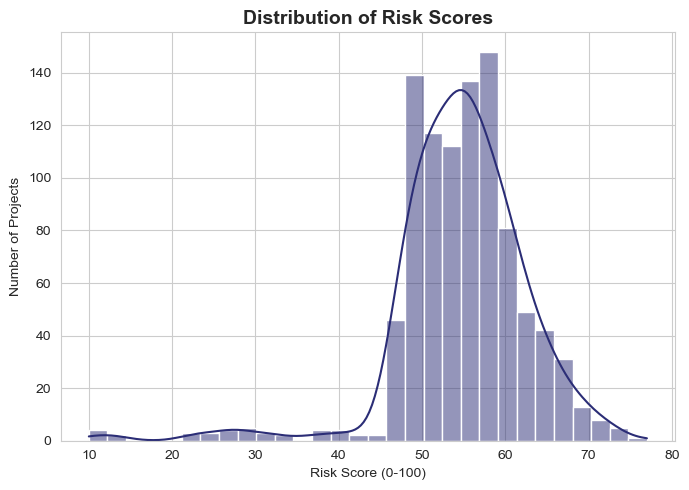

In [39]:
# Chart 3 — Risk Score Distribution
plt.figure(figsize=(7,5))
sns.histplot(df_clean['Risk_Score_0_100'], bins=30, kde=True, color="#2b2d76")
plt.title("Distribution of Risk Scores", fontsize=14, fontweight='bold')
plt.xlabel("Risk Score (0-100)")
plt.ylabel("Number of Projects")
plt.tight_layout()
plt.savefig("visuals/03_risk_score_distribution.png", dpi=200)
plt.show()

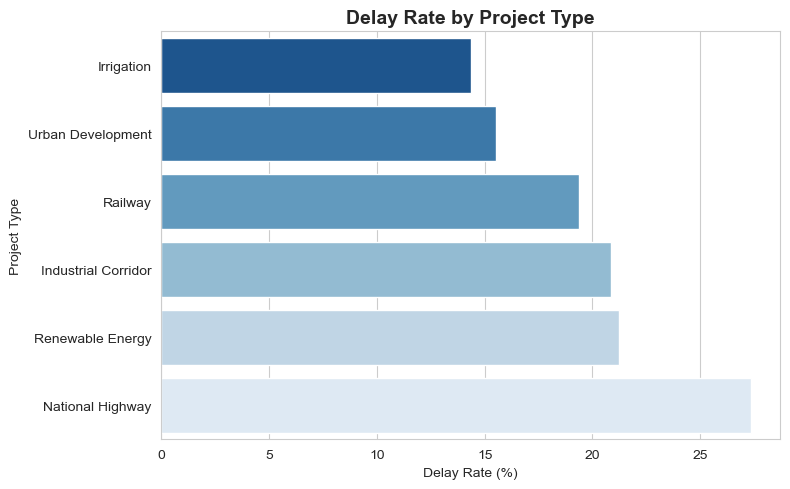

In [40]:
# Chart 4 — Delay Rate by Project Type
plt.figure(figsize=(8,5))
type_delay = df_clean.groupby('Project_Type')['Delay_Label'].mean().sort_values() * 100
sns.barplot(x=type_delay.values, y=type_delay.index, hue=type_delay.index, palette="Blues_r", legend=False)
plt.title("Delay Rate by Project Type", fontsize=14, fontweight='bold')
plt.xlabel("Delay Rate (%)")
plt.ylabel("Project Type")
plt.tight_layout()
plt.savefig("visuals/04_delay_by_project_type.png", dpi=200)
plt.show()

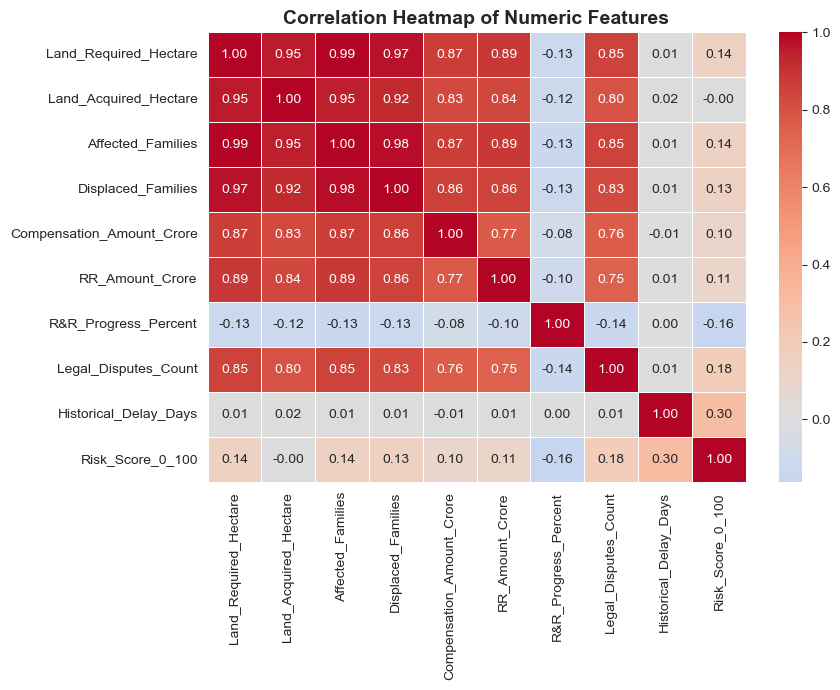

In [41]:
# Chart 5 — Correlation Heatmap
plt.figure(figsize=(9,7))
num_cols = ['Land_Required_Hectare','Land_Acquired_Hectare','Affected_Families',
            'Displaced_Families','Compensation_Amount_Crore','RR_Amount_Crore',
            'R&R_Progress_Percent','Legal_Disputes_Count','Historical_Delay_Days',
            'Risk_Score_0_100']
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("visuals/05_correlation_heatmap.png", dpi=200)
plt.show()

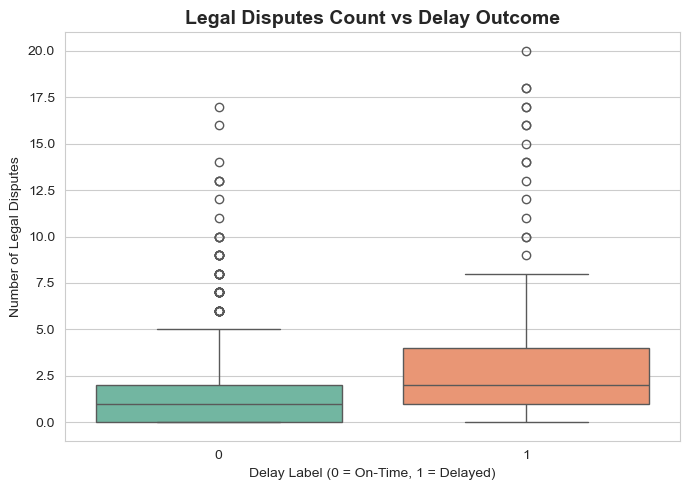

In [42]:
# Chart 6 — Legal Disputes vs Delay
plt.figure(figsize=(7,5))
sns.boxplot(x='Delay_Label', y='Legal_Disputes_Count', data=df_clean, hue='Delay_Label', palette="Set2", legend=False)
plt.title("Legal Disputes Count vs Delay Outcome", fontsize=14, fontweight='bold')
plt.xlabel("Delay Label (0 = On-Time, 1 = Delayed)")
plt.ylabel("Number of Legal Disputes")
plt.tight_layout()
plt.savefig("visuals/06_legal_disputes_vs_delay.png", dpi=200)
plt.show()

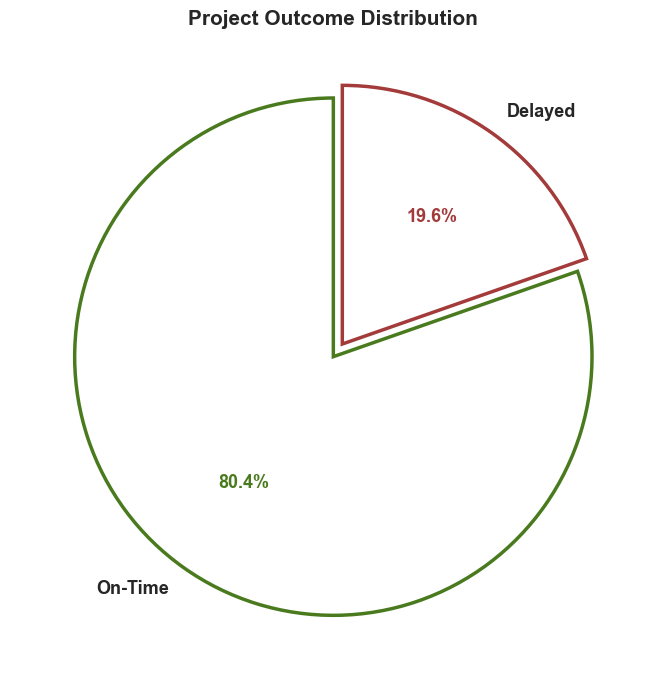

In [43]:
# Chart 7 — Project Outcome Distribution (outline-style pie chart)
plt.figure(figsize=(7,7))
counts = df_clean['Delay_Label'].value_counts().sort_index()
labels = ['On-Time', 'Delayed']
edge_colors = ['#4a7a1e', '#a43b3b']
explode = (0, 0.06)

wedges, texts, autotexts = plt.pie(
    counts, labels=labels, autopct='%1.1f%%', startangle=90,
    explode=explode, textprops={'fontsize':13, 'fontweight':'bold'},
    wedgeprops={'linewidth':2.5}
)
for wedge, color in zip(wedges, edge_colors):
    wedge.set_facecolor('none')
    wedge.set_edgecolor(color)
for autotext, color in zip(autotexts, edge_colors):
    autotext.set_color(color)

plt.title('Project Outcome Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("visuals/07_delay_pie_chart_outline.png", dpi=200, transparent=True)
plt.show()

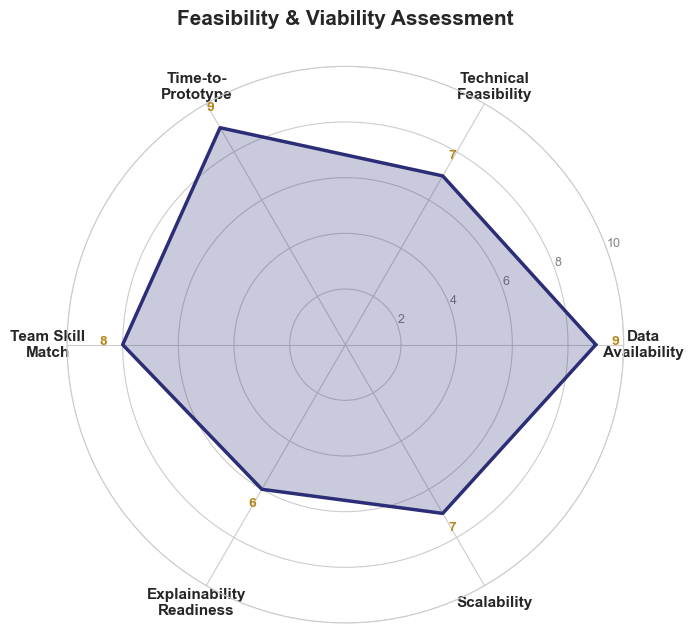

In [44]:
# Chart 8 — Feasibility & Viability Radar Chart
categories = ['Data\nAvailability', 'Technical\nFeasibility', 'Time-to-\nPrototype',
              'Team Skill\nMatch', 'Explainability\nReadiness', 'Scalability']
scores = [9, 7, 9, 8, 6, 7]  # out of 10 — team's feasibility self-assessment

N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
scores_plot = scores + scores[:1]
angles_plot = angles + angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
ax.plot(angles_plot, scores_plot, color='#2b2d76', linewidth=2.5)
ax.fill(angles_plot, scores_plot, color='#2b2d76', alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 10)
ax.set_yticks([2,4,6,8,10])
ax.set_yticklabels(['2','4','6','8','10'], fontsize=9, color='gray')
ax.set_rlabel_position(20)
for angle, score in zip(angles, scores):
    ax.annotate(str(score), xy=(angle, score), xytext=(angle, score+0.7),
                fontsize=10, fontweight='bold', color='#b5871a', ha='center')

plt.title('Feasibility & Viability Assessment', fontsize=15, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig("visuals/08_feasibility_radar.png", dpi=200, transparent=True)
plt.show()

## 4. Train Phase — Classification Model (Delay_Label)

**IMPORTANT FIX:** `Historical_Delay_Days` is now also dropped from the feature set below. It was accidentally left in during earlier iterations — since a project's own historical delay count almost directly gives away whether it was delayed, leaving it in was a leakage risk for classification too, not just for the later regression model. Expect classification metrics to shift slightly (likely still good, but now honestly earned).

In [45]:
# Drop ALL leakage-prone / non-feature columns:
# - Delay_Label, Risk_Score_0_100 -> these ARE the target / directly determine it
# - Historical_Delay_Days -> near-direct proxy for the target, must exclude (this was the missed leak)
# - Project_ID, Data_Basis -> identifiers/metadata, not predictive features

features = df_clean.drop(columns=[
    'Delay_Label', 'Risk_Score_0_100', 'Historical_Delay_Days', 'Project_ID', 'Data_Basis'
])
target = df_clean['Delay_Label']

features.head()

,State,District,Project_Type,Land_Required_Hectare,Land_Acquired_Hectare,Affected_Families,Displaced_Families,Sanction_Date,3A_Notification_Date,3D_Notification_Date,Award_Date,Payment_Date,Possession_Date,Compensation_Amount_Crore,RR_Amount_Crore,Compensation_Status,R&R_Progress_Percent,Legal_Disputes_Count,Possession_Status,date_issue
2,Odisha,Sambalpur,Urban Development,84.41,33.67,164,26,2018-11-25,2019-12-18,2020-09-27,2024-05-18,2026-01-06,2026-05-28,214.35,10.61,Pending,100.0,4,Pending,False
4,West Bengal,Kolkata,Irrigation,29.96,23.30,48,8,2022-03-02,2023-01-22,2024-08-15,2025-06-07,2025-08-22,2027-08-02,53.02,5.04,Partially paid,86.7,1,Partial possession,False
5,Tamil Nadu,Madurai,National Highway,88.53,50.36,158,35,2020-08-01,2021-05-17,2023-08-06,2024-05-11,2025-03-26,2026-08-19,364.77,10.93,Pending,91.7,2,Pending,False
11,Odisha,Cuttack,National Highway,42.51,19.81,83,18,2023-07-28,2025-03-10,2027-09-13,2028-04-26,2028-06-15,2029-03-25,88.51,2.42,Pending,90.4,1,Pending,False
12,Odisha,Cuttack,Urban Development,22.29,19.25,42,6,2016-08-12,2016-10-17,2017-04-05,2021-08-02,2022-12-07,2024-08-30,21.13,0.94,Partially paid,91.4,0,Partial possession,False


In [46]:
# Convert key date gaps into numeric features (days)
# NOTE: these are fine as features for the CLASSIFICATION target (Delay_Label) —
# the leakage issue we found earlier was specific to using them to predict Historical_Delay_Days directly.
features['Days_Sanction_to_3A'] = (df_clean['3A_Notification_Date'] - df_clean['Sanction_Date']).dt.days
features['Days_3A_to_3D'] = (df_clean['3D_Notification_Date'] - df_clean['3A_Notification_Date']).dt.days
features['Days_3D_to_Award'] = (df_clean['Award_Date'] - df_clean['3D_Notification_Date']).dt.days
features['Days_Award_to_Payment'] = (df_clean['Payment_Date'] - df_clean['Award_Date']).dt.days
features['Days_Payment_to_Possession'] = (df_clean['Possession_Date'] - df_clean['Payment_Date']).dt.days

date_cols_to_drop = ['Sanction_Date','3A_Notification_Date','3D_Notification_Date',
                     'Award_Date','Payment_Date','Possession_Date']
features = features.drop(columns=date_cols_to_drop + ['date_issue'])

features.head()

,State,District,Project_Type,Land_Required_Hectare,Land_Acquired_Hectare,Affected_Families,Displaced_Families,Compensation_Amount_Crore,RR_Amount_Crore,Compensation_Status,R&R_Progress_Percent,Legal_Disputes_Count,Possession_Status,Days_Sanction_to_3A,Days_3A_to_3D,Days_3D_to_Award,Days_Award_to_Payment,Days_Payment_to_Possession
2,Odisha,Sambalpur,Urban Development,84.41,33.67,164,26,214.35,10.61,Pending,100.0,4,Pending,388,284,1329,598,142
4,West Bengal,Kolkata,Irrigation,29.96,23.30,48,8,53.02,5.04,Partially paid,86.7,1,Partial possession,326,571,296,76,710
5,Tamil Nadu,Madurai,National Highway,88.53,50.36,158,35,364.77,10.93,Pending,91.7,2,Pending,289,811,279,319,511
11,Odisha,Cuttack,National Highway,42.51,19.81,83,18,88.51,2.42,Pending,90.4,1,Pending,591,917,226,50,283
12,Odisha,Cuttack,Urban Development,22.29,19.25,42,6,21.13,0.94,Partially paid,91.4,0,Partial possession,66,170,1580,492,632


In [47]:
features_encoded = pd.get_dummies(features, columns=[
    'State', 'District', 'Project_Type', 'Compensation_Status', 'Possession_Status'
], drop_first=True)

print(features_encoded.shape)
features_encoded.head()

(967, 74)


,Land_Required_Hectare,Land_Acquired_Hectare,Affected_Families,Displaced_Families,Compensation_Amount_Crore,RR_Amount_Crore,R&R_Progress_Percent,Legal_Disputes_Count,Days_Sanction_to_3A,Days_3A_to_3D,...,District_Varanasi,Project_Type_Irrigation,Project_Type_National Highway,Project_Type_Railway,Project_Type_Renewable Energy,Project_Type_Urban Development,Compensation_Status_Partially paid,Compensation_Status_Pending,Possession_Status_Pending,Possession_Status_Substantially complete
2,84.41,33.67,164,26,214.35,10.61,100.0,4,388,284,...,False,False,False,False,False,True,False,True,True,False
4,29.96,23.30,48,8,53.02,5.04,86.7,1,326,571,...,False,True,False,False,False,False,True,False,False,False
5,88.53,50.36,158,35,364.77,10.93,91.7,2,289,811,...,False,False,True,False,False,False,False,True,True,False
11,42.51,19.81,83,18,88.51,2.42,90.4,1,591,917,...,False,False,True,False,False,False,False,True,True,False
12,22.29,19.25,42,6,21.13,0.94,91.4,0,66,170,...,False,False,False,False,False,True,True,False,False,False


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (773, 74) Test size: (194, 74)


### Baseline model — Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluate

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       156
           1       0.82      0.87      0.85        38

    accuracy                           0.94       194
   macro avg       0.90      0.91      0.90       194
weighted avg       0.94      0.94      0.94       194

ROC-AUC: 0.969804318488529
Confusion Matrix:
 [[149   7]
 [  5  33]]


### Train XGBoost and compare against Random Forest

In [51]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  # handles class imbalance
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_preds))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       156
           1       0.78      0.92      0.84        38

    accuracy                           0.93       194
   macro avg       0.88      0.93      0.90       194
weighted avg       0.94      0.93      0.94       194

ROC-AUC: 0.9735155195681512


In [52]:
pd.Series(xgb_probs * 100).describe()

count    194.000000
mean      22.724514
std       39.951298
min        0.002685
25%        0.010252
50%        0.043510
75%       11.872152
max       99.984322
dtype: float64

## 5. SHAP Explainability

In [53]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

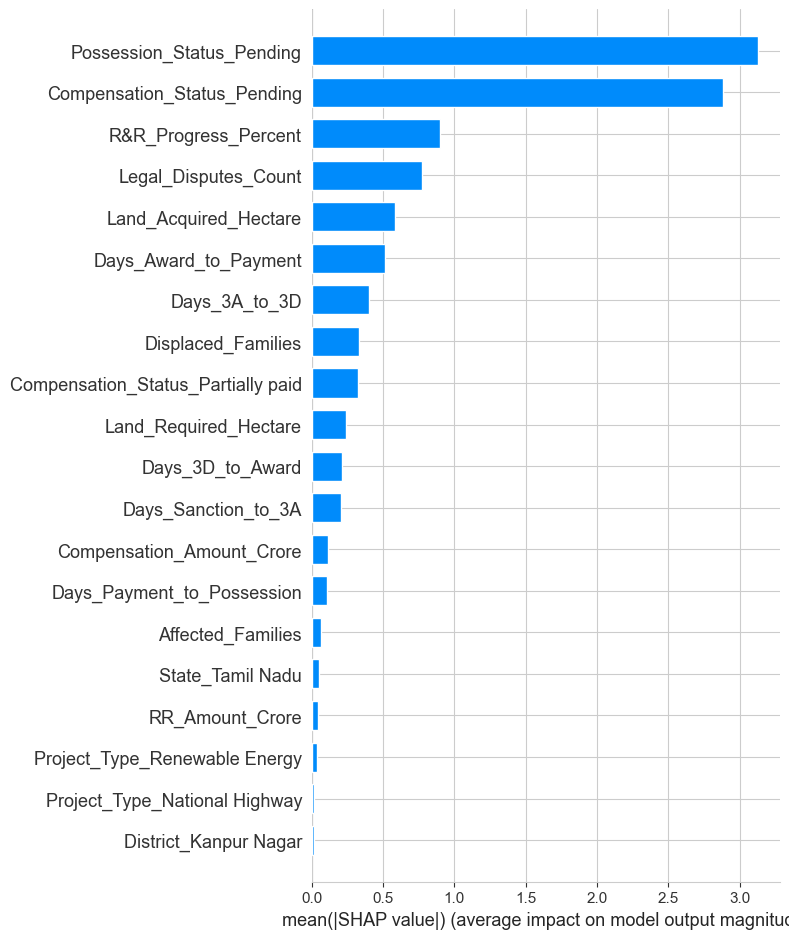

In [54]:
# Global feature importance — bar chart
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("visuals/09_shap_feature_importance_bar.png", dpi=200, bbox_inches='tight')
plt.show()

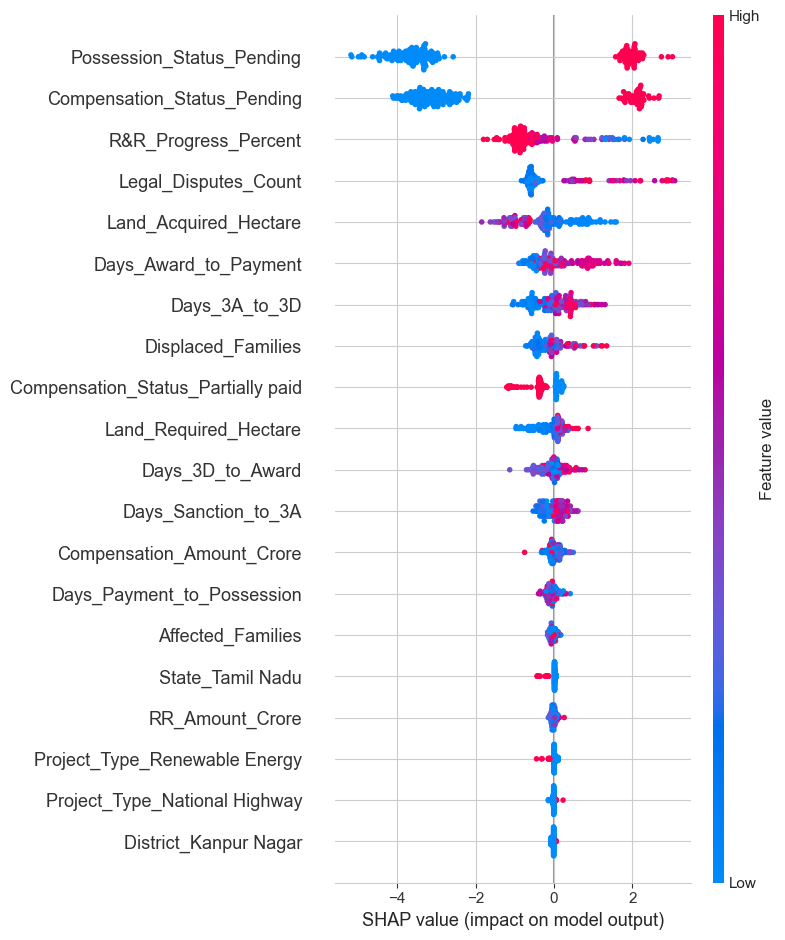

In [55]:
# Detailed summary plot — shows direction of impact too
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("visuals/10_shap_summary_beeswarm.png", dpi=200, bbox_inches='tight')
plt.show()

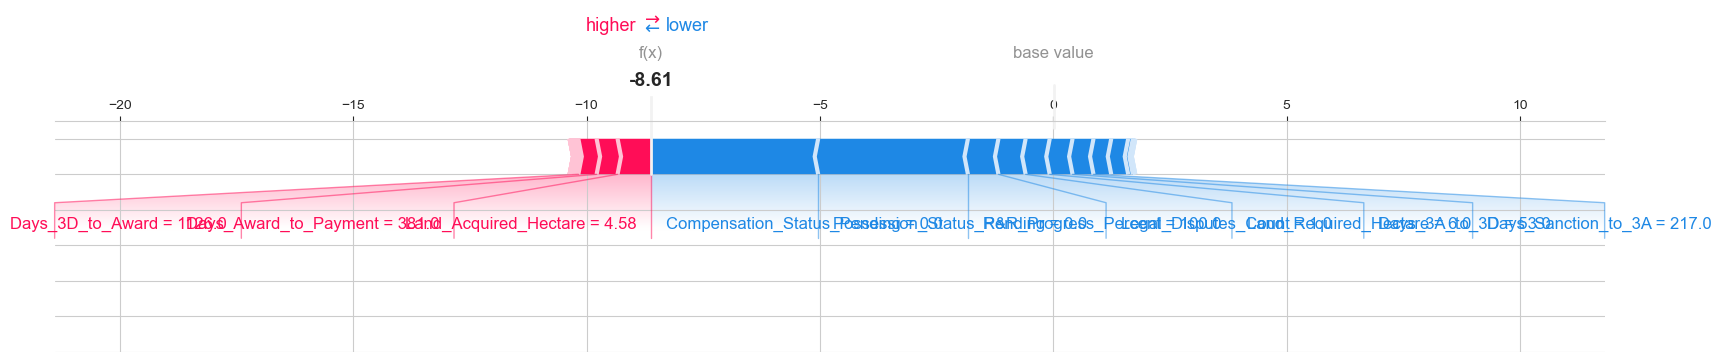

In [56]:
# Explain ONE specific project's prediction
sample_idx = 0
shap.force_plot(
    explainer.expected_value, shap_values[sample_idx], X_test.iloc[sample_idx],
    matplotlib=True, show=False
)
plt.savefig("visuals/11_shap_force_plot_sample.png", dpi=200, bbox_inches='tight')
plt.show()

## 6. Save Classification Model, Explainer & Feature List

In [57]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(xgb_model, "models/risk_model.pkl")
joblib.dump(explainer, "models/shap_explainer.pkl")
joblib.dump(list(X_train.columns), "models/feature_columns.pkl")

print("Model, explainer, and feature list saved successfully in models/ folder")
print(os.listdir("models"))

Model, explainer, and feature list saved successfully in models/ folder
['feature_columns.pkl', 'risk_model.pkl', 'shap_explainer.pkl', 'time_feature_columns.pkl', 'time_model.pkl']


## 7. Regression Model — Predicting Delay Duration (Historical_Delay_Days)

**IMPORTANT FIX:** Two leaks were found and are both excluded below:
1. The 5 engineered date-gap features (`Days_Sanction_to_3A` etc.) — these were used to *construct* `Historical_Delay_Days` in the synthetic dataset, so including them let the model just reconstruct the answer instead of predicting it (this produced the fake 0.9999 R² we saw earlier).
2. `Historical_Delay_Days` itself — it was accidentally still present as a column in `features_encoded_no_leak` (confirmed via `'Historical_Delay_Days' in features_encoded_no_leak.columns` returning `True`). This is the real target variable, so it must never appear as an input feature.

In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg_target = df_clean['Historical_Delay_Days']

# Drop BOTH leak sources: the 5 date-gap features AND Historical_Delay_Days itself
leak_prone_cols = ['Days_Sanction_to_3A', 'Days_3A_to_3D', 'Days_3D_to_Award',
                    'Days_Award_to_Payment', 'Days_Payment_to_Possession']

features_for_regression = features_encoded.drop(columns=leak_prone_cols, errors='ignore')

# Safety check — confirm no leakage columns remain before training
assert 'Historical_Delay_Days' not in features_for_regression.columns, "Leak still present!"
assert 'Risk_Score_0_100' not in features_for_regression.columns, "Leak still present!"
print("No leakage columns detected. Proceeding with", features_for_regression.shape[1], "features.")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    features_for_regression, reg_target, test_size=0.2, random_state=42
)

No leakage columns detected. Proceeding with 69 features.


In [59]:
time_model = RandomForestRegressor(n_estimators=200, random_state=42)
time_model.fit(X_train_reg, y_train_reg)

time_preds = time_model.predict(X_test_reg)

print("MAE (days):", mean_absolute_error(y_test_reg, time_preds))
print("R² Score:", r2_score(y_test_reg, time_preds))

MAE (days): 515.4826546391753
R² Score: -0.05994232630499341


### Save the time-prediction model

In [60]:
joblib.dump(time_model, "models/time_model.pkl")
joblib.dump(list(features_for_regression.columns), "models/time_feature_columns.pkl")
print("Time prediction model and its feature list saved")

Time prediction model and its feature list saved


# new "next ML model"

In [61]:
# ============================================================
# Module A: Cost Prediction Model (Compensation_Amount_Crore)
# ============================================================

# Only use features genuinely known at project-planning stage —
# deliberately excluding RR_Amount_Crore and Legal_Disputes_Count,
# since those aren't naturally "known in advance" for a new project being planned
cost_features = df_clean[['State', 'Project_Type', 'Land_Required_Hectare',
                           'Affected_Families', 'Displaced_Families']]
cost_features_encoded = pd.get_dummies(cost_features, columns=['State', 'Project_Type'], drop_first=True)
cost_target = df_clean['Compensation_Amount_Crore']

X_train_cost, X_test_cost, y_train_cost, y_test_cost = train_test_split(
    cost_features_encoded, cost_target, test_size=0.2, random_state=42
)

cost_model = RandomForestRegressor(n_estimators=200, random_state=42)
cost_model.fit(X_train_cost, y_train_cost)

cost_preds = cost_model.predict(X_test_cost)
print("MAE (Crore):", mean_absolute_error(y_test_cost, cost_preds))
print("R² Score:", r2_score(y_test_cost, cost_preds))

MAE (Crore): 54.45591056701028
R² Score: 0.672914642149509


In [63]:
# Save it
joblib.dump(cost_model, "models/cost_model.pkl")
joblib.dump(list(cost_features_encoded.columns), "models/cost_feature_columns.pkl")
print("Cost model saved")

Cost model saved


In [64]:
def calculate_land_feasibility(land_type, land_required, land_acquired_so_far,
                                 affected_families, legal_disputes, rr_progress):
    """
    Returns a Land Feasibility Score (0-100, higher = more feasible)
    based on transparent, weighted rules.
    """
    score = 100

    # Land type risk weights (forest/tribal land is harder to acquire)
    land_type_penalty = {
        'Forest': 25, 'Tribal': 20, 'Government': 5,
        'Agricultural': 10, 'Private': 15
    }
    score -= land_type_penalty.get(land_type, 10)

    # Acquisition progress so far (less progress = lower feasibility right now)
    progress_pct = (land_acquired_so_far / land_required * 100) if land_required > 0 else 0
    if progress_pct < 30:
        score -= 15
    elif progress_pct < 60:
        score -= 7

    # Scale of displacement (more families = harder)
    if affected_families > 500:
        score -= 15
    elif affected_families > 200:
        score -= 8

    # Legal disputes directly reduce feasibility
    score -= min(legal_disputes * 4, 20)

    # R&R progress improves feasibility
    score += (rr_progress / 100) * 10

    return max(0, min(100, round(score, 1)))

In [65]:
# Example: a relatively easy case
print(calculate_land_feasibility('Government', 100, 60, 150, 1, 70))

# Example: a genuinely hard case
print(calculate_land_feasibility('Forest', 100, 20, 600, 8, 20))

98.0
27.0
